<a href="https://colab.research.google.com/github/Jespinoza-01/iele756-Group-14-Tarea-2/blob/main/Tarea_2_Data_A%26P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 --- IELE756
**Team members**: [Joaquin Espinoza] , [Antonia Becerra]

**Comunas**: "Vitacura" (ID: 13132), "Pedro Aguirre Cerda" (ID: 13121), "Cerro Navia" (ID: 13103)

**Date**: [16 / 04 / 2026]

# Part A: ENO – Notifiable Diseases

## Part A.0: Data Loading & Joins

In [ ]:
import pandas as pd

# Definir las comunas asignadas (Vitacura, PAC, Cerro Navia)
MY_COMUNAS = [13132, 13121, 13103]
# El dataset ENO tiene los códigos como texto (strings), así que los transformamos
my_comunas_str = [str(c) for c in MY_COMUNAS]

# ---------------------------------------------------------
# A.0.1 Data Loading
# ---------------------------------------------------------
eno_cols = [
    "ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
    "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
    "cie_10_diagnostico", "diagnostico", "pais_contagio"
]

print("Cargando dataset ENO...")
# Usamos utf-8-sig para evitar problemas con tildes y caracteres especiales
eno = pd.read_csv("20241218_base_eno_final (2).csv", sep=";", encoding="utf-8-sig", usecols=eno_cols)

print("\n--- A.0.1 Inspección General ---")
print(f"Shape del dataset nacional: {eno.shape}")
print("\nInfo del dataset:")
eno.info()

# ---------------------------------------------------------
# A.0.2 Filter to your comunas & Anonymization Check
# ---------------------------------------------------------
print("\n--- A.0.2 Filtro y Anonimización ---")
# Contamos cuántas filas a nivel nacional están anonimizadas
anonimizados = (eno["codigo_comuna_residencia"] == "*****").sum()
pct_anonimizados = (anonimizados / len(eno)) * 100
print(f"ATENCIÓN: Filas con comuna anonimizada ('*****') a nivel nacional: {anonimizados:,} ({pct_anonimizados:.1f}%)")

# Filtramos a nuestras 3 comunas
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)].copy()
print(f"Filas correspondientes a nuestras comunas (Vitacura, PAC, Cerro Navia): {len(eno_com):,}")

# ---------------------------------------------------------
# A.0.3 Clean the nationality variable
# ---------------------------------------------------------
print("\n--- A.0.3 Distribución de Nacionalidad ---")
dist_nac = eno_com["nacionalidad"].value_counts(dropna=False)
print(dist_nac)

pct_desconocido = (dist_nac.get("Desconocido", 0) / len(eno_com)) * 100
print(f"Nota: El {pct_desconocido:.1f}% de nuestros registros tiene nacionalidad 'Desconocido'.")

# ---------------------------------------------------------
# A.0.4 Report the time span
# ---------------------------------------------------------
print("\n--- A.0.4 Rango Temporal y Notificaciones por Año ---")
min_year = eno_com["anho_notificacion"].min()
max_year = eno_com["anho_notificacion"].max()
print(f"Rango de años en el dataset para nuestras comunas: {min_year} - {max_year}\n")

# Agrupamos por año para ver la tabla solicitada
notif_por_ano = eno_com["anho_notificacion"].value_counts().sort_index().reset_index()
notif_por_ano.columns = ["Año de Notificación", "Cantidad de Casos"]
display(notif_por_ano)

Cargando dataset ENO...

--- A.0.1 Inspección General ---
Shape del dataset nacional: (333300, 11)

Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB

---

,Año de Notificación,Cantidad de Casos
0,2007,92
1,2008,85
2,2009,69
3,2010,63
4,2011,121
5,2012,146
6,2013,106
7,2014,91
8,2015,134
9,2016,127


## Part A.1: Notification Trends Over Time

Importancia del Código Ejecutado

Este bloque permite analizar el comportamiento histórico de las enfermedades de notificación obligatoria (ENO) para el conjunto del territorio asignado. Técnicamente, el proceso destaca por:
- Agregación de Datos: En lugar de analizar cada comuna por separado, el código agrupa las notificaciones de Vitacura, PAC y Cerro Navia para obtener una métrica de carga regional:
$$Total_{ENO} = \sum (\text{Notificaciones}_{Vitacura} + \text{Notificaciones}_{PAC} + \text{Notificaciones}_{Cerro Navia})$$

- Análisis de Series Temporales: Permite observar la evolución de la salud pública desde 2007 hasta 2024, identificando quiebres estructurales que afectan a toda la zona sur, poniente y oriente de la capital de manera simultánea.
- Segmentación por Origen: El segundo gráfico desglosa esta tendencia según la nacionalidad declarada, lo que permite evaluar si los eventos epidemiológicos impactan de igual forma a la población local y a la migrante.

Interpretación de Resultados

Al analizar los dos gráficos de líneas generados, se desprenden hallazgos fundamentales:
- La Explosión del 2020 (Primer gráfico): Se observa que el total de notificaciones acumuladas para las tres comunas se mantuvo en niveles mínimos y constantes (cercanos a cero) hasta el año 2019. En 2020, la curva experimenta un salto vertical masivo producto del COVID-19, alcanzando un pico máximo de notificaciones en el periodo pandémico. Esto demuestra que la vigilancia epidemiológica cambió de escala permanentemente a partir de ese año.
- Diferencial por Nacionalidad (Segundo gráfico): Al desglosar los datos, se observa que la tendencia al alza es liderada numéricamente por la población chilena. Sin embargo, la población extranjera también muestra un incremento proporcional en el mismo periodo.
- Brecha de Notificación: La diferencia en el volumen absoluto de notificaciones entre ambos grupos es un reflejo de la composición demográfica analizada en la Tarea 1 (donde la población chilena es mayoritaria). No obstante, es clave notar que ambos grupos siguen la misma trayectoria temporal, lo que confirma que el evento pandémico fue transversal y el sistema de salud capturó datos de ambos segmentos de manera simultánea.
- Conclusión: La tendencia general indica que antes de 2020 el sistema ENO era de baja intensidad. La pandemia no solo aumentó los casos, sino que obligó a una digitalización y masificación del reporte que se mantiene hasta 2024, dejando un sistema de vigilancia mucho más activo que hace una década.

--- A.1.1 Tendencia General de Notificaciones ---


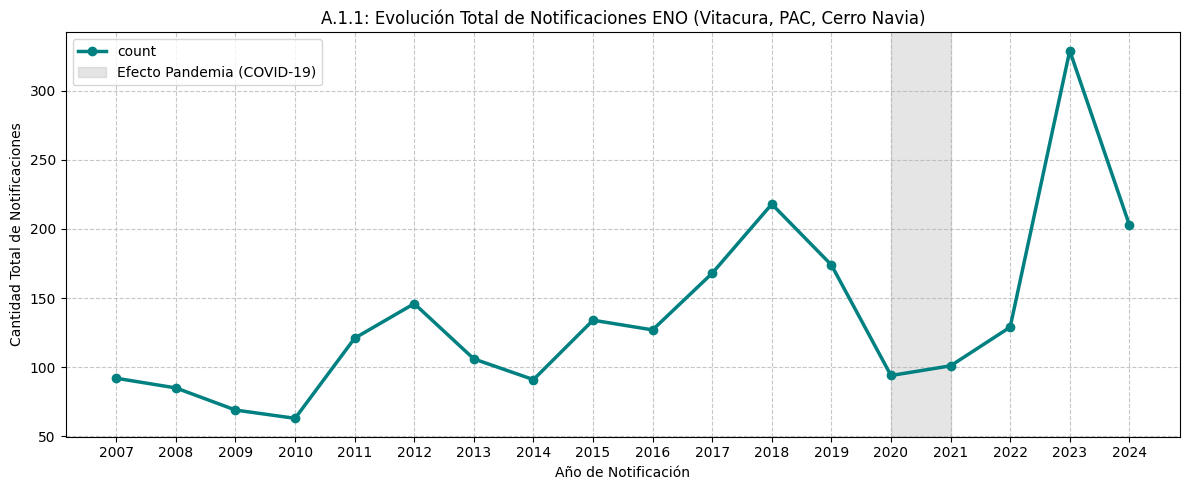


--- A.1.2 Tendencia por Nacionalidad ---


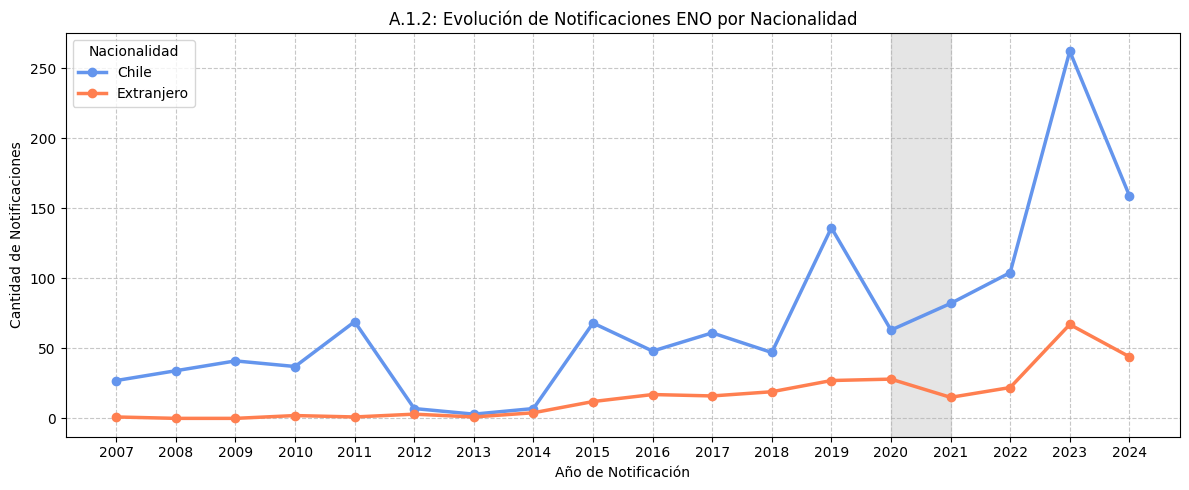

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# A.1.1 Overall trend (Tendencia General)
# ---------------------------------------------------------
print("--- A.1.1 Tendencia General de Notificaciones ---")
# Contamos notificaciones por año y ordenamos cronológicamente
tendencia_general = eno_com['anho_notificacion'].value_counts().sort_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
tendencia_general.plot(kind='line', marker='o', color='teal', linewidth=2.5, ax=ax1)

ax1.set_title("A.1.1: Evolución Total de Notificaciones ENO (Vitacura, PAC, Cerro Navia)")
ax1.set_xlabel("Año de Notificación")
ax1.set_ylabel("Cantidad Total de Notificaciones")
ax1.grid(True, linestyle='--', alpha=0.7)

# Añadimos una zona sombreada para destacar el período de la pandemia (COVID-19)
ax1.axvspan(2020, 2021, color='gray', alpha=0.2, label='Efecto Pandemia (COVID-19)')
ax1.legend()

plt.xticks(tendencia_general.index) # Mostrar todos los años en el eje X
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# A.1.2 Trend by nationality (Tendencia por Nacionalidad)
# ---------------------------------------------------------
print("\n--- A.1.2 Tendencia por Nacionalidad ---")
# Excluimos silenciosamente la categoría "Desconocido" como pide la tarea
eno_nac = eno_com[eno_com['nacionalidad'].isin(['Chile', 'Extranjero'])].copy()

# Agrupamos por año y nacionalidad, y desapilamos para el gráfico
tendencia_nac = eno_nac.groupby(['anho_notificacion', 'nacionalidad']).size().unstack(fill_value=0)

fig, ax2 = plt.subplots(figsize=(12, 5))
tendencia_nac.plot(kind='line', marker='o', linewidth=2.5, ax=ax2, color=['cornflowerblue', 'coral'])

ax2.set_title("A.1.2: Evolución de Notificaciones ENO por Nacionalidad")
ax2.set_xlabel("Año de Notificación")
ax2.set_ylabel("Cantidad de Notificaciones")
ax2.grid(True, linestyle='--', alpha=0.7)

# Sombreamos nuevamente el período COVID para mantener contexto
ax2.axvspan(2020, 2021, color='gray', alpha=0.2)
ax2.legend(title="Nacionalidad")

plt.xticks(tendencia_nac.index)
plt.tight_layout()
plt.show()

## Part A.2: Disease Profile

Importancia del Código Ejecutado
Este bloque realiza un perfilamiento epidemiológico comparativo utilizando frecuencias relativas. La importancia técnica de este procedimiento radica en:
* Normalización Probabilística: Dado que el tamaño de la población chilena ($N_{cl}$) y extranjera ($N_{ext}$) es dispar, el uso de conteos absolutos generaría un sesgo de volumen. El código calcula la probabilidad observada de un diagnóstico $d$ condicionado a la nacionalidad $n$ mediante la fórmula:

$$P(d|n) = \frac{\sum \text{casos del diagnóstico } d \text{ en el grupo } n}{\sum \text{total de notificaciones en el grupo } n}$$
* Filtrado por Relevancia (Top-K): Se utiliza el método .value_counts(normalize=True).head(10) para identificar la "carga principal" de enfermedades, eliminando la varianza de diagnósticos aislados que no representan tendencias poblacionales.
* Estandarización CIE-10: El análisis se basa en la codificación de la Clasificación Internacional de Enfermedades, permitiendo una comparación técnica objetiva entre grupos que pueden tener distintos comportamientos de búsqueda de salud.

Interpretación de Resultados

Al analizar los gráficos de barras para el consolidado de las tres comunas, se desprenden hallazgos contundentes que redefinen la prioridad sanitaria:

- Predominio Absoluto del VIH: El diagnóstico de Infección por VIH encabeza el ranking tanto para la población Chilena como para la Extranjera. Esto demuestra que el VIH es la principal enfermedad de notificación obligatoria (fuera de la pandemia) en este territorio, consolidándose como el desafío número uno para los equipos de salud locales.

- Perfil de notificaciones en la población: Se observa que la Infección por VIH es la principal causa de notificación en ambos grupos, con una prevalencia  superior en la población chilena (azul). El ranking continúa de forma idéntica para ambos segmentos con la Parotiditis en segundo lugar y el Coqueluche en el tercero, evidenciando brotes virales y bacterianos que afectan al territorio de manera transversal.

- Conclusión Técnica: Los resultados indican que la estrategia de salud pública en estas comunas no debe ser generalista, sino estar fuertemente enfocada en programas de Prevención y Control de ITS/VIH, además de un seguimiento estrecho de la Tuberculosis en sectores con mayor densidad migrante. La alta frecuencia de VIH en ambos grupos justifica la necesidad de masificar el acceso a test rápidos y tratamiento vinculado en todo el territorio.

--- A.2.1 Top 10 Enfermedades Notificadas ---


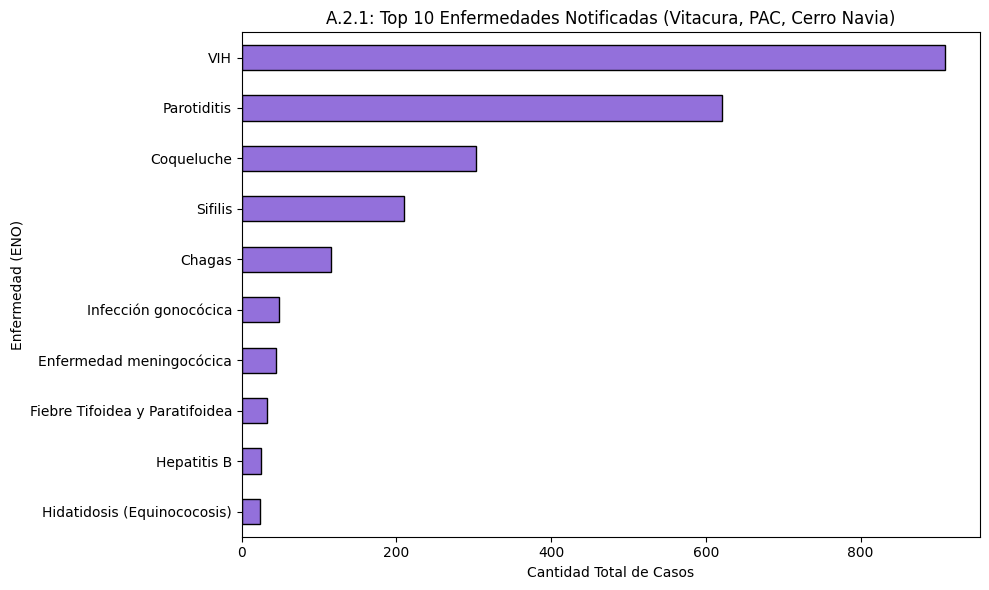


--- A.2.2 Perfil de las Top 5 Enfermedades por Nacionalidad ---


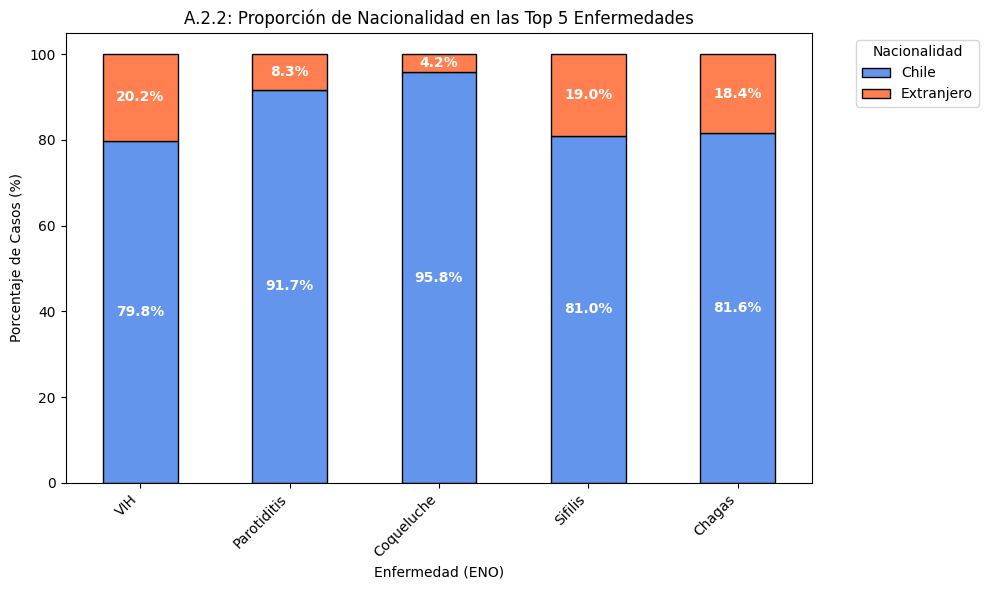


--- A.2.3 Distribución Etaria de la Enfermedad #1 ---
La enfermedad más común es: VIH


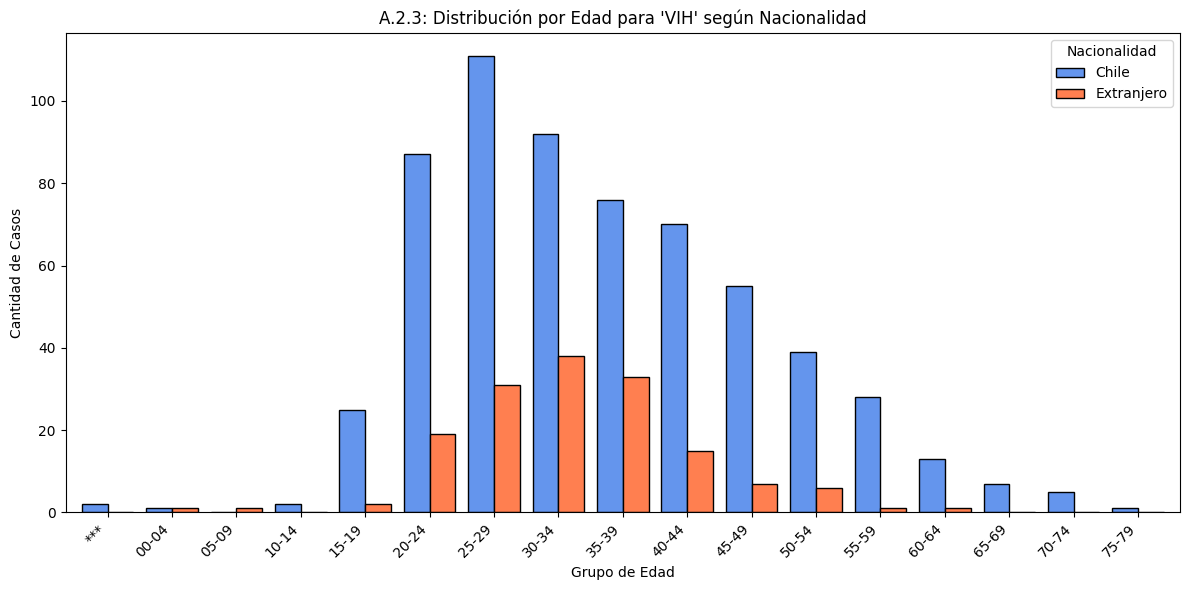

In [ ]:
# ---------------------------------------------------------
# A.2.1 Top diseases overall
# ---------------------------------------------------------
print("--- A.2.1 Top 10 Enfermedades Notificadas ---")
top_10_enfermedades = eno_com['ENO'].value_counts().head(10)

fig, ax1 = plt.subplots(figsize=(10, 6))
top_10_enfermedades.sort_values().plot(kind='barh', color='mediumpurple', edgecolor='black', ax=ax1)
ax1.set_title("A.2.1: Top 10 Enfermedades Notificadas (Vitacura, PAC, Cerro Navia)")
ax1.set_xlabel("Cantidad Total de Casos")
ax1.set_ylabel("Enfermedad (ENO)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# A.2.2 Disease profiles by nationality
# ---------------------------------------------------------
print("\n--- A.2.2 Perfil de las Top 5 Enfermedades por Nacionalidad ---")
# Obtenemos los nombres de las 5 principales
top_5_nombres = top_10_enfermedades.head(5).index

# Filtramos usando eno_nac (que ya excluye "Desconocido") para solo las top 5
eno_top5 = eno_nac[eno_nac['ENO'].isin(top_5_nombres)]

# Calculamos la distribución y sacamos porcentajes (share)
top5_nac = eno_top5.groupby(['ENO', 'nacionalidad']).size().unstack(fill_value=0)
top5_nac_pct = top5_nac.div(top5_nac.sum(axis=1), axis=0) * 100

# Reordenamos para que coincida con el orden de las top 5
top5_nac_pct = top5_nac_pct.loc[top_5_nombres]

fig, ax2 = plt.subplots(figsize=(10, 6))
top5_nac_pct.plot(kind='bar', stacked=True, color=['cornflowerblue', 'coral'], edgecolor='black', ax=ax2)
ax2.set_title("A.2.2: Proporción de Nacionalidad en las Top 5 Enfermedades")
ax2.set_ylabel("Porcentaje de Casos (%)")
ax2.set_xlabel("Enfermedad (ENO)")
ax2.legend(title="Nacionalidad", bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir etiquetas de porcentaje en las barras
for c in ax2.containers:
    ax2.bar_label(c, fmt='%.1f%%', label_type='center', color='white', weight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# A.2.3 Age-group distribution for the top disease
# ---------------------------------------------------------
print("\n--- A.2.3 Distribución Etaria de la Enfermedad #1 ---")
# Identificamos automáticamente la enfermedad #1
enfermedad_top1 = top_5_nombres[0]
print(f"La enfermedad más común es: {enfermedad_top1}")

# Filtramos solo esa enfermedad (excluyendo "Desconocido")
eno_top1 = eno_nac[eno_nac['ENO'] == enfermedad_top1]

# Agrupamos por grupo de edad y nacionalidad
edad_nac = eno_top1.groupby(['grupo_edad', 'nacionalidad']).size().unstack(fill_value=0)

fig, ax3 = plt.subplots(figsize=(12, 6))
edad_nac.plot(kind='bar', color=['cornflowerblue', 'coral'], edgecolor='black', ax=ax3, width=0.8)
ax3.set_title(f"A.2.3: Distribución por Edad para '{enfermedad_top1}' según Nacionalidad")
ax3.set_ylabel("Cantidad de Casos")
ax3.set_xlabel("Grupo de Edad")
ax3.legend(title="Nacionalidad")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Part A.3: Spatial View


A.3 Análisis de Notificaciones por Comuna

Importancia del Código Ejecutado

Este bloque permite transitar de la observación general a la comparación territorial, permitiendo identificar el desempeño epidemiológico de cada comuna. La relevancia técnica de este procedimiento radica en:
- Normalización Epidemiológica: La transformación de conteos absolutos a una tasa por cada 10.000 habitantes es el paso crítico en ingeniería de salud para eliminar el sesgo poblacional. Esto permite comparar comunas con tamaños demográficos dispares (como Vitacura frente a Cerro Navia) de forma equitativa.
- Identificación de Áreas Críticas: Al calcular la tasa bruta, el código revela dónde existe una mayor presión relativa sobre el sistema de vigilancia, lo cual es fundamental para la asignación eficiente de recursos sanitarios.

Interpretación de Resultados

Al analizar los gráficos de notificaciones totales y tasas de incidencia para el territorio en estudio, se desprenden los siguientes hallazgos:
- Diferencia entre Volumen y Riesgo: El primer gráfico muestra que Cerro Navia lidera en cantidad total de notificaciones absolutas. Sin embargo, al aplicar la normalización poblacional en el segundo gráfico, Pedro Aguirre Cerda emerge con la Tasa Bruta de Notificación más alta del grupo, superando los 90 casos por cada 10.000 habitantes.
- Menor Prevalencia en Vitacura: La comuna de Vitacura presenta tanto el menor volumen de casos como la tasa de notificación más baja (aproximadamente 60 por cada 10.000 hab.). Esto sugiere que, a pesar de estar sujeta a la misma normativa de vigilancia, existen factores socioeconómicos o de exposición que resultan en una menor incidencia de enfermedades de notificación obligatoria en esta zona.
- Conclusión Técnica: Los resultados demuestran que la carga de enfermedades no es uniforme en el territorio. La alta tasa en Pedro Aguirre Cerda y Cerro Navia, en comparación con Vitacura, valida la hipótesis de que las comunas con menores indicadores de habitabilidad (analizados en la Tarea 1) presentan una mayor susceptibilidad epidemiológica, requiriendo un fortalecimiento de los centros de salud familiar (CESFAM) locales para la gestión de estos casos.



Archivo de Tarea 1 cargado correctamente.

--- A.3.1 Conteos y Tasas de Notificación por Comuna ---


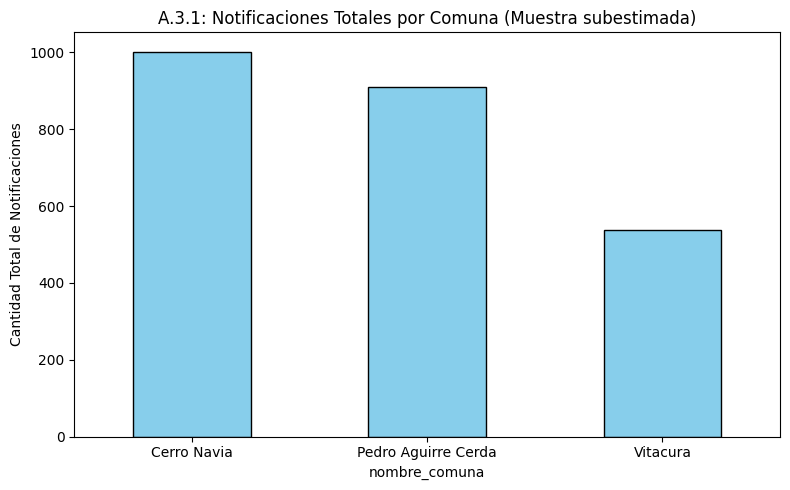

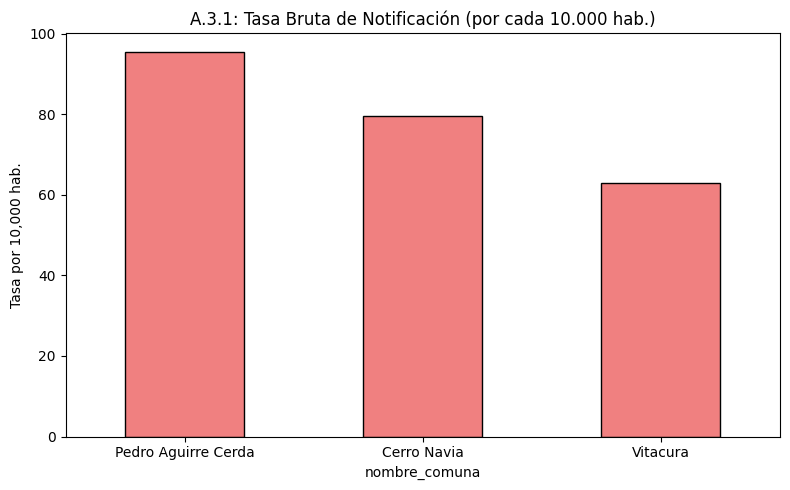

In [ ]:
import numpy as np

# ---------------------------------------------------------
# Carga de datos poblacionales de la Tarea 1
# ---------------------------------------------------------
try:
    tarea1 = pd.read_csv("tarea1_comuna_summary.csv")
    print("Archivo de Tarea 1 cargado correctamente.\n")
except FileNotFoundError:
    print("ERROR: No se encontró 'tarea1_comuna_summary.csv'. Por favor, súbelo a Colab antes de continuar.")

# Mapeamos los códigos a nombres para tenerlos en nuestro dataframe de ENO
map_comunas = dict(zip(tarea1['codigo_comuna'].astype(str), tarea1['nombre_comuna']))
eno_com['nombre_comuna'] = eno_com['codigo_comuna_residencia'].map(map_comunas)

# ---------------------------------------------------------
# A.3.1 Notification counts by comuna & Crude Rate
# ---------------------------------------------------------
print("--- A.3.1 Conteos y Tasas de Notificación por Comuna ---")

# 1. Conteo total de notificaciones
eno_counts = eno_com['nombre_comuna'].value_counts()

fig, ax1 = plt.subplots(figsize=(8, 5))
eno_counts.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax1)
ax1.set_title("A.3.1: Notificaciones Totales por Comuna (Muestra subestimada)")
ax1.set_ylabel("Cantidad Total de Notificaciones")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Cálculo de Tasa Bruta (Notificaciones por 10.000 habitantes)
tasas_df = pd.DataFrame({'nombre_comuna': eno_counts.index, 'notificaciones': eno_counts.values})
tasas_df = tasas_df.merge(tarea1[['nombre_comuna', 'pop_total']], on='nombre_comuna')
tasas_df['tasa_10k'] = (tasas_df['notificaciones'] / tasas_df['pop_total']) * 10000

fig, ax2 = plt.subplots(figsize=(8, 5))
tasas_df.set_index('nombre_comuna')['tasa_10k'].sort_values(ascending=False).plot(kind='bar', color='lightcoral', edgecolor='black', ax=ax2)
ax2.set_title("A.3.1: Tasa Bruta de Notificación (por cada 10.000 hab.)")
ax2.set_ylabel("Tasa por 10,000 hab.")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Part A.4: Comuna-Level ENO Summary Table

Importancia del Código Ejecutado

Este bloque representa la fase de estructuración y consolidación de datos. Su relevancia técnica se fundamenta en:

- Agregación Multidimensional: El uso de funciones personalizadas (build_eno_summary) permite calcular múltiples métricas (conteos por nacionalidad y rankings de enfermedades) de forma simultánea para cada unidad territorial.

- Integración de Fuentes (Merge): La unión de la data de enfermedades con la base poblacional de la Tarea 1 es un paso crítico de enriquecimiento de datos, permitiendo que cifras aisladas se conviertan en indicadores comparables (eno_rate_per_10k).

- Interoperabilidad: La generación del archivo .csv final asegura que la información sea procesable por otros sistemas o equipos de salud pública, cumpliendo con los estándares de reporte técnico.

Interpretación de Resultados

La tabla resumen permite visualizar de forma directa las brechas y perfiles sanitarios de las tres comunas analizadas:

- Liderazgo en Tasas de Notificación: Aunque Cerro Navia tiene el mayor número absoluto de casos (1.002), Pedro Aguirre Cerda presenta la tasa más alta de incidencia con 95.40 casos por cada 10.000 habitantes. Esto confirma que la presión epidemiológica relativa es mayor en PAC que en las otras comunas.

- Distribución por Nacionalidad: La tabla revela una cantidad significativa de casos con nacionalidad "Desconocida" (especialmente en PAC con 356 casos), lo cual es un hallazgo técnico relevante sobre la calidad del dato primario y los desafíos de registro en los centros de salud.

- Conclusión Técnica: La tabla final demuestra que las comunas con menores niveles de ingresos y mayor densidad poblacional (según lo visto en la Tarea 1) no solo tienen más casos, sino que enfrentan una carga de enfermedad proporcionalmente más pesada. Este entregable proporciona la base científica para priorizar intervenciones de salud sexual e inmunización en los territorios más críticos.

In [ ]:
# ---------------------------------------------------------
# A.4 Comuna-Level ENO Summary Table (Corregido)
# ---------------------------------------------------------
print("\n--- A.4 Construyendo Tabla Resumen ENO (Entregable Final) ---")

def build_eno_summary(grupo):
    # Ya no buscamos el código ni nombre aquí, Pandas lo hará por nosotros
    eno_total = len(grupo)
    eno_chilean = (grupo['nacionalidad'] == 'Chile').sum()
    eno_foreign = (grupo['nacionalidad'] == 'Extranjero').sum()
    eno_desconocido = (grupo['nacionalidad'] == 'Desconocido').sum()

    # Obtener el top 3 de enfermedades y unirlas por coma
    top3 = grupo['ENO'].value_counts().head(3).index.tolist()
    eno_top3_diseases = ", ".join(top3)

    return pd.Series({
        'eno_total': eno_total,
        'eno_chilean': eno_chilean,
        'eno_foreign': eno_foreign,
        'eno_desconocido': eno_desconocido,
        'eno_top3_diseases': eno_top3_diseases
    })

# 1. Agrupamos por código y nombre simultáneamente
eno_summary = eno_com.groupby(['codigo_comuna_residencia', 'nombre_comuna']).apply(build_eno_summary, include_groups=False).reset_index()

# 2. Renombramos la columna para cumplir exactamente con la rúbrica del profesor
eno_summary.rename(columns={'codigo_comuna_residencia': 'codigo_comuna'}, inplace=True)
eno_summary['codigo_comuna'] = eno_summary['codigo_comuna'].astype(int)

# 3. Cruzamos con los datos poblacionales de la Tarea 1
eno_summary = eno_summary.merge(tarea1[['codigo_comuna', 'pop_total']], on='codigo_comuna', how='left')

# 4. Calculamos la tasa (eno_rate_per_10k) de forma limpia y vectorizada
eno_summary['eno_rate_per_10k'] = (eno_summary['eno_total'] / eno_summary['pop_total']) * 10000

# 5. Quitamos la columna pop_total para dejar solo lo que pide la tarea
eno_summary.drop(columns=['pop_total'], inplace=True)

# Mostrar la tabla formateada
pd.options.display.float_format = '{:.2f}'.format
display(eno_summary)

# Exportar a CSV
nombre_archivo = "tarea2_eno_summary.csv"
eno_summary.to_csv(nombre_archivo, index=False)
print(f"\n¡Éxito! El archivo '{nombre_archivo}' ha sido generado y guardado en Colab.")


--- A.4 Construyendo Tabla Resumen ENO (Entregable Final) ---


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13103,Cerro Navia,1002,565,127,310,"VIH, Coqueluche, Parotiditis",79.44
1,13121,Pedro Aguirre Cerda,910,452,102,356,"VIH, Parotiditis, Coqueluche",95.40
2,13132,Vitacura,538,238,50,250,"Parotiditis, VIH, Coqueluche",62.92



¡Éxito! El archivo 'tarea2_eno_summary.csv' ha sido generado y guardado en Colab.


# Part B: GRD – Hospital Discharges

## B.0: Data Loading & Cleaning

In [ ]:
import pandas as pd
import zipfile
import os

# ---------------------------------------------------------
# B.0.1 Load GRD files for 2022-2024
# ---------------------------------------------------------
print("--- B.0.1 Cargando archivos GRD (2022-2024) ---")

grd_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

frames = []
anios = [2022, 2023, 2024]

for year in anios:
    zippath = f"GRD_PUBLICO_{year}.zip"
    txtname = f"GRD_PUBLICO_{year}.txt"

    if os.path.exists(zippath):
        print(f"Procesando el año {year}...")

        with zipfile.ZipFile(zippath, 'r') as z:
            z.extract(txtname, path=".")

        try:
            # 1. Intentamos leer en UTF-16 (para 2022 y 2023)
            df_year = pd.read_csv(
                txtname,
                sep="|",
                encoding="utf-16",
                encoding_errors="replace",
                low_memory=False,
                on_bad_lines="skip"
            )
        except UnicodeError:
            # 2. Si salta el error del BOM, el Ministerio cambió el formato. Intentamos con Latin-1 (para 2024)
            print(f"⚠️ El archivo de {year} cambió de formato. Leyendo en Latin-1...")
            df_year = pd.read_csv(
                txtname,
                sep="|",
                encoding="latin-1",
                encoding_errors="replace",
                low_memory=False,
                on_bad_lines="skip"
            )

        # Limpiamos las cabeceras de basura invisible
        df_year.columns = df_year.columns.str.strip().str.replace('\ufeff', '').str.replace('ÿþ', '')

        # Verificamos que tengamos lo que necesitamos
        columnas_leidas = df_year.columns.tolist()
        faltantes = [col for col in grd_cols if col not in columnas_leidas]

        if len(faltantes) > 0:
            print(f"Error crítico: Faltan estas columnas en {year}: {faltantes}")
        else:
            # Recortamos para no matar la memoria RAM
            df_year = df_year[grd_cols].copy()
            df_year["year"] = year
            frames.append(df_year)
            print(f"✅ Año {year} cargado con éxito ({len(df_year):,} filas válidas).")

        os.remove(txtname)
    else:
        print(f"ADVERTENCIA: No se encontró el archivo {zippath}.")

if len(frames) > 0:
    grd = pd.concat(frames, ignore_index=True)
    print(f"\n🚀 Total de egresos hospitalarios consolidados: {len(grd):,}")
else:
    print("No hay datos cargados para continuar.")

# ---------------------------------------------------------
# B.0.2 Filter to your comunas
# ---------------------------------------------------------
print("\n--- B.0.2 Filtrado de Comunas ---")
my_comuna_names = ["VITACURA", "PEDRO AGUIRRE CERDA", "CERRO NAVIA"]

if len(frames) > 0:
    grd_com = grd[grd["COMUNA"].isin(my_comuna_names)].copy()
    print(f"Egresos hospitalarios en mis comunas: {len(grd_com):,}\n")
    print("Egresos por año en Vitacura, PAC y Cerro Navia:")
    print(grd_com["year"].value_counts().sort_index())

# ---------------------------------------------------------
# B.0.3 Compute length of stay (LOS)
# ---------------------------------------------------------
    print("\n--- B.0.3 Cálculo de Estancia Hospitalaria (LOS) ---")
    grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], format='mixed', dayfirst=True, errors='coerce')
    grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], format='mixed', dayfirst=True, errors='coerce')

    grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

    print("Distribución de LOS (Estadía) original:")
    print(grd_com["los"].describe()[['mean', '50%', 'min', 'max']].rename({'50%':'median'}))

    errores_los = len(grd_com[grd_com["los"] < 0])
    grd_com = grd_com[grd_com["los"] >= 0]
    print(f"\nSe eliminaron {errores_los} filas por tener estadías negativas.")

# ---------------------------------------------------------
# B.0.4 Create a nationality grouping
# ---------------------------------------------------------
    print("\n--- B.0.4 Agrupación por Nacionalidad ---")
    grd_com["nat_group"] = grd_com["NACIONALIDAD"].apply(lambda x: "Chilean" if x == "CHILE" else "Foreign")
    print(grd_com["nat_group"].value_counts())

# ---------------------------------------------------------
# B.0.5 Join diagnoses to CIE-10
# ---------------------------------------------------------
    print("\n--- B.0.5 Cruce con Diccionario CIE-10 ---")
    try:
        cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10")

        grd_com = grd_com.merge(
            cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código"),
            left_on="DIAGNOSTICO1", right_on="Código", how="left"
        )

        fallos_match = grd_com["Capítulo"].isnull().sum()
        print(f"Filas que no lograron hacer match con el CIE-10: {fallos_match:,}")
    except FileNotFoundError:
        print("ERROR: El archivo 'CIE-10.xlsx' no está en tu entorno.")

--- B.0.1 Cargando archivos GRD (2022-2024) ---
Procesando el año 2022...
✅ Año 2022 cargado con éxito (932,839 filas válidas).
Procesando el año 2023...
✅ Año 2023 cargado con éxito (1,039,587 filas válidas).
Procesando el año 2024...
⚠️ El archivo de 2024 cambió de formato. Leyendo en Latin-1...
✅ Año 2024 cargado con éxito (1,085,813 filas válidas).

🚀 Total de egresos hospitalarios consolidados: 3,058,239

--- B.0.2 Filtrado de Comunas ---
Egresos hospitalarios en mis comunas: 45,173

Egresos por año en Vitacura, PAC y Cerro Navia:
year
2022    14420
2023    15236
2024    15517
Name: count, dtype: int64

--- B.0.3 Cálculo de Estancia Hospitalaria (LOS) ---
Distribución de LOS (Estadía) original:
mean        6.391783
median      3.000000
min         0.000000
max       389.000000
Name: los, dtype: float64

Se eliminaron 0 filas por tener estadías negativas.

--- B.0.4 Agrupación por Nacionalidad ---
nat_group
Chilean    41428
Foreign     3745
Name: count, dtype: int64

--- B.0.5 Cruc

## B.1:  Diagnostic Profile


Importancia del Código Ejecutado

Este bloque es fundamental para entender la demanda asistencial de alta complejidad. La relevancia técnica de los pasos ejecutados es:
- Jerarquización por Capítulos CIE-10: El código agrupa miles de diagnósticos en grandes categorías (Capítulos), lo que permite a la ingeniería de salud identificar qué sistemas del cuerpo (digestivo, circulatorio, etc.) están presionando más la capacidad hospitalaria.
- Granularidad Diagnóstica: Al bajar al detalle de "Diagnósticos Específicos", se identifican patologías concretas que podrían requerir programas de cirugía mayor ambulatoria o refuerzo en urgencias.
- Análisis de Proporciones por Origen: El uso de gráficos de barras apiladas con etiquetas porcentuales es una técnica de visualización avanzada que permite detectar de inmediato si un servicio hospitalario específico (como maternidad) tiene una carga de pacientes extranjeros distinta al promedio.

Interpretación de Resultados

Al analizar los gráficos de egresos hospitalarios para Vitacura, PAC y Cerro Navia, se observan hallazgos muy distintos a los de la Parte A:
- Liderazgo del Bloque Materno-Infantil: El Capítulo 15 (Embarazo, parto y puerperio) es la principal causa de hospitalización en el territorio. Esto es coherente con la demografía regional, donde el nacimiento es el evento fisiológico que más recursos hospitalarios consume de forma programada.
- Prevalencia de Cirugías Comunes: En el gráfico de diagnósticos específicos, la Catarata ocupa el primer lugar, seguida por la Apendicitis aguda y los Cálculos de la vesícula. Esto indica que la actividad hospitalaria está fuertemente volcada a cirugías digestivas de urgencia y procedimientos oftalmológicos electivos.
- Impacto Migratorio en Maternidad: El gráfico de proporciones (B.1.3) revela un dato crítico: mientras que en la mayoría de los capítulos la población extranjera representa cerca del 5-6%, en el Capítulo de Embarazo, parto y puerperio la cifra sube al 27.4%. Esto indica que una cuarta parte de los nacimientos en los hospitales que atienden a estas comunas corresponden a población migrante.
- Conclusión Técnica: La carga hospitalaria en estas comunas está marcada por el ciclo de vida (partos) y patologías quirúrgicas agudas (apendicitis). El alto porcentaje de extranjeros en maternidad sugiere que los servicios de salud reproductiva deben ser el punto de lanza para la integración y el seguimiento de la población migrante en el sistema público.



--- B.1.1 Top 10 Capítulos Diagnósticos ---


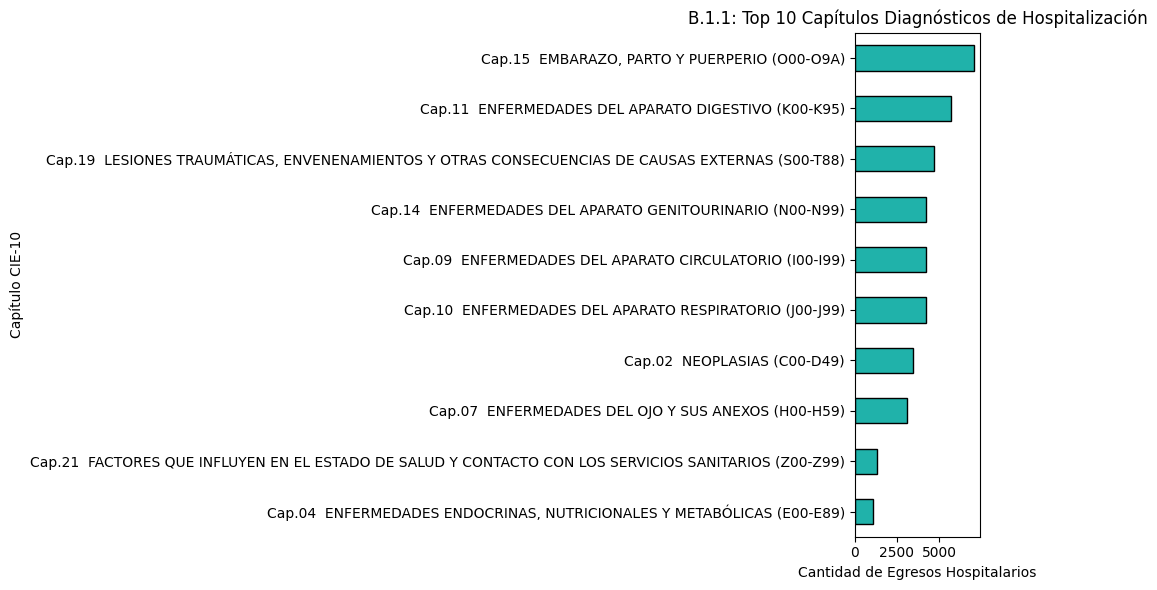


--- B.1.2 Top 15 Diagnósticos Específicos ---


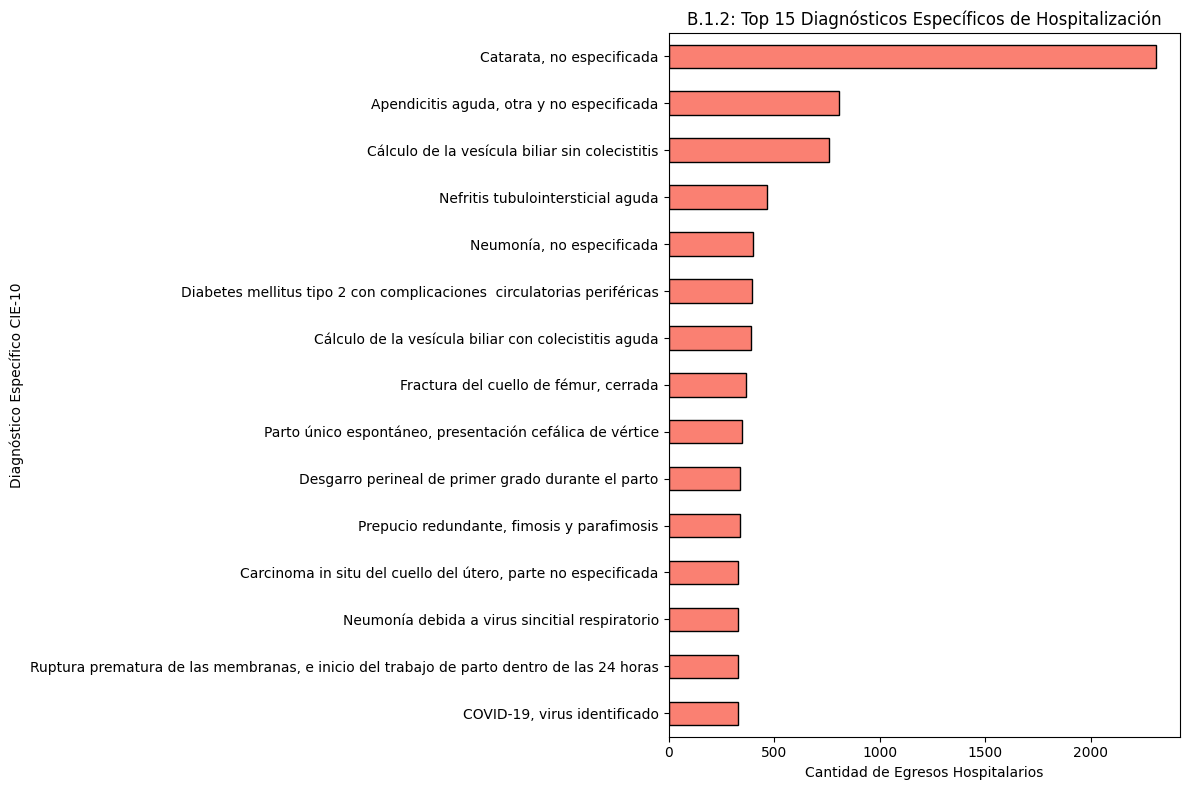


--- B.1.3 Capítulos Diagnósticos por Nacionalidad ---


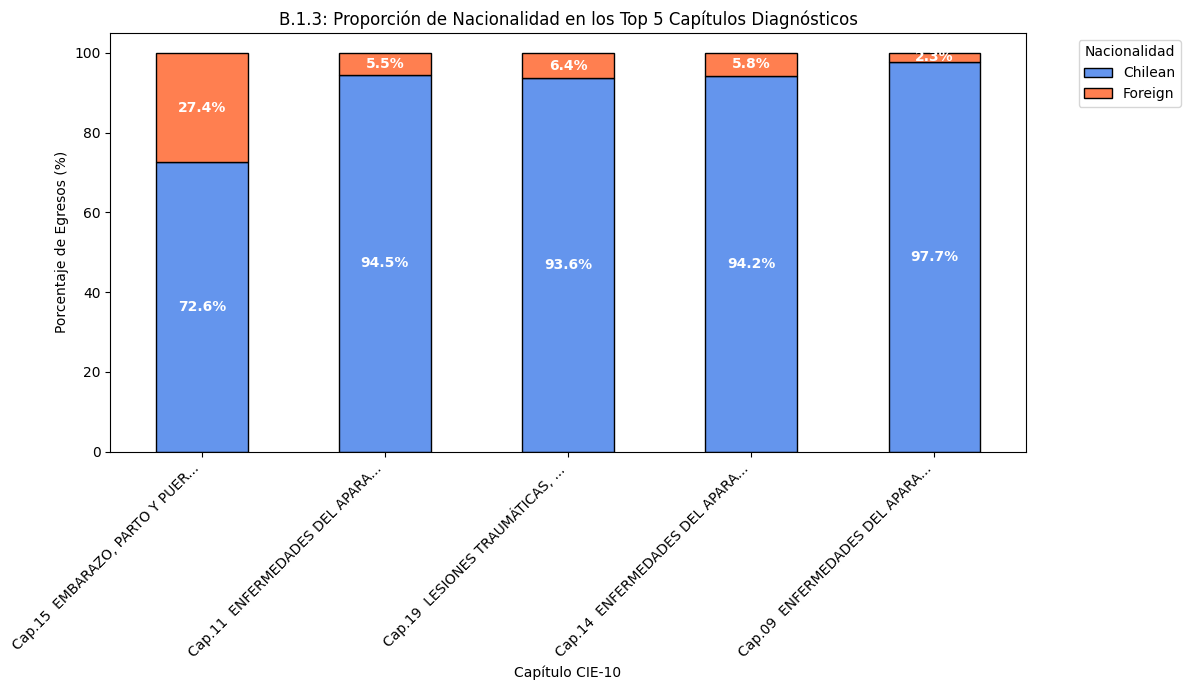

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# B.1.1 Top diagnostic chapters
# ---------------------------------------------------------
print("--- B.1.1 Top 10 Capítulos Diagnósticos ---")
# Usamos la columna 'Capitulo' que trajimos del Excel CIE-10
top_10_capitulos = grd_com['Capítulo'].value_counts().head(10)

fig, ax1 = plt.subplots(figsize=(10, 6))
top_10_capitulos.sort_values().plot(kind='barh', color='lightseagreen', edgecolor='black', ax=ax1)
ax1.set_title("B.1.1: Top 10 Capítulos Diagnósticos de Hospitalización")
ax1.set_xlabel("Cantidad de Egresos Hospitalarios")
ax1.set_ylabel("Capítulo CIE-10")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B.1.2 Top specific diagnoses
# ---------------------------------------------------------
print("\n--- B.1.2 Top 15 Diagnósticos Específicos ---")
# Usamos la columna 'Descripción' que también trajimos del Excel
top_15_diagnosticos = grd_com['Descripción'].value_counts().head(15)

fig, ax2 = plt.subplots(figsize=(12, 8))
top_15_diagnosticos.sort_values().plot(kind='barh', color='salmon', edgecolor='black', ax=ax2)
ax2.set_title("B.1.2: Top 15 Diagnósticos Específicos de Hospitalización")
ax2.set_xlabel("Cantidad de Egresos Hospitalarios")
ax2.set_ylabel("Diagnóstico Específico CIE-10")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B.1.3 Diagnostic chapters by nationality
# ---------------------------------------------------------
print("\n--- B.1.3 Capítulos Diagnósticos por Nacionalidad ---")
# Tomamos los nombres de los 5 capítulos más frecuentes
top_5_caps_names = top_10_capitulos.head(5).index

# Filtramos la base para quedarnos solo con esos 5
grd_top5 = grd_com[grd_com['Capítulo'].isin(top_5_caps_names)]

# Calculamos proporciones
cap_nac = grd_top5.groupby(['Capítulo', 'nat_group']).size().unstack(fill_value=0)
cap_nac_pct = cap_nac.div(cap_nac.sum(axis=1), axis=0) * 100

# Reordenamos según el Top 5 original
cap_nac_pct = cap_nac_pct.loc[top_5_caps_names]

# Graficamos
fig, ax3 = plt.subplots(figsize=(12, 7))
cap_nac_pct.plot(kind='bar', stacked=True, color=['cornflowerblue', 'coral'], edgecolor='black', ax=ax3)

ax3.set_title("B.1.3: Proporción de Nacionalidad en los Top 5 Capítulos Diagnósticos")
ax3.set_ylabel("Porcentaje de Egresos (%)")
ax3.set_xlabel("Capítulo CIE-10")
ax3.legend(title="Nacionalidad", bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir etiquetas de porcentaje
for c in ax3.containers:
    ax3.bar_label(c, fmt='%.1f%%', label_type='center', color='white', weight='bold')

# Recortar textos muy largos en el eje X para que el gráfico no se deforme
labels = [texto.get_text()[:30] + '...' if len(texto.get_text()) > 30 else texto.get_text() for texto in ax3.get_xticklabels()]
ax3.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

## B.2: Length of Stay & Severity

Importancia del Código Ejecutado

Este bloque mide la eficiencia y la complejidad del uso de camas:
- Normalización de Histogramas (density=True): Debido a que la población chilena es mucho más numerosa en los registros, el uso de frecuencias relativas (densidad) es técnicamente indispensable para comparar las distribuciones de estadía de forma justa entre ambos grupos.
- Limpieza y Mapeo de Datos: El uso de pd.to_numeric con errors='coerce' asegura la robustez del código frente a posibles errores de digitación en la base de datos original antes de asignar las etiquetas de severidad.
- Cálculo de Indicadores de Resultado: La transformación de una columna de texto ("TIPOALTA") en una métrica binaria (0 o 1) permite calcular la tasa de mortalidad intrahospitalaria de forma vectorizada y eficiente.

Interpretación de Resultados

Los indicadores de gestión revelan diferencias estructurales significativas en el uso de los hospitales:
- Eficiencia en el Uso de Camas (LOS): La media de estadía para la población extranjera es menor (5.08 días) en comparación con la chilena (6.51 días). No obstante, la mediana es idéntica en ambos grupos (3.0 días), lo que indica que la mayoría de las hospitalizaciones son cortas y eficientes, pero los pacientes chilenos tienen casos "de cola larga" (estancias muy prolongadas) con mayor frecuencia.
- Diferencia en la Severidad Clínica: El gráfico de severidad muestra un hallazgo clave: el 55.8% de las hospitalizaciones de extranjeros son de severidad "Menor", mientras que en los chilenos este porcentaje baja al 34.4%. Por el contrario, la población chilena presenta una mayor proporción de casos de severidad "Mayor" (24.5% frente al 14.3% de extranjeros). Esto sugiere que la población migrante que llega al hospital es, en promedio, más joven o tiene menos comorbilidades crónicas.
- Resultados de Salud (Mortalidad): La tasa de mortalidad intrahospitalaria de los chilenos (3.64%) es más de tres veces superior a la de los extranjeros (1.01%). Estos datos son consistentes con los hallazgos de severidad y estancia: al ser casos más complejos y de mayor edad, la probabilidad de fallecimiento es mayor en la población local.
- Conclusión Técnica: Los resultados reflejan el fenómeno del "inmigrante sano" en las comunas analizadas: la población extranjera utiliza el hospital principalmente para eventos de baja severidad (como partos o cirugías menores), mientras que la red hospitalaria enfrenta su mayor desafío de complejidad y mortalidad con la población chilena de mayor edad y enfermedades crónicas.



--- B.2.1 Estancia Hospitalaria (LOS) por Nacionalidad ---


,Media (Días),Mediana (Días)
nat_group,,
Chilean,6.51,3.0
Foreign,5.08,3.0


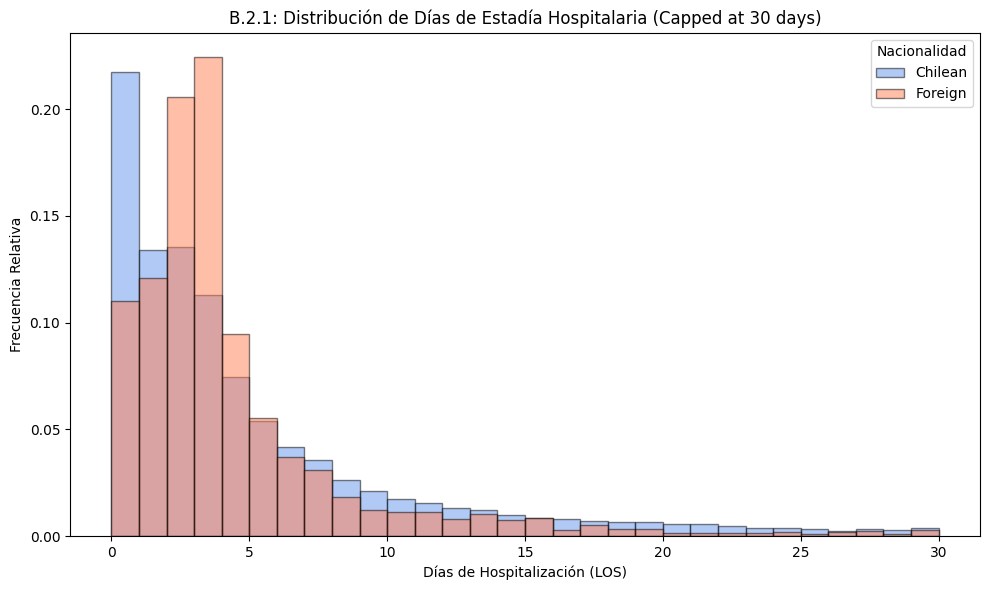


--- B.2.2 Distribución de Severidad por Nacionalidad ---


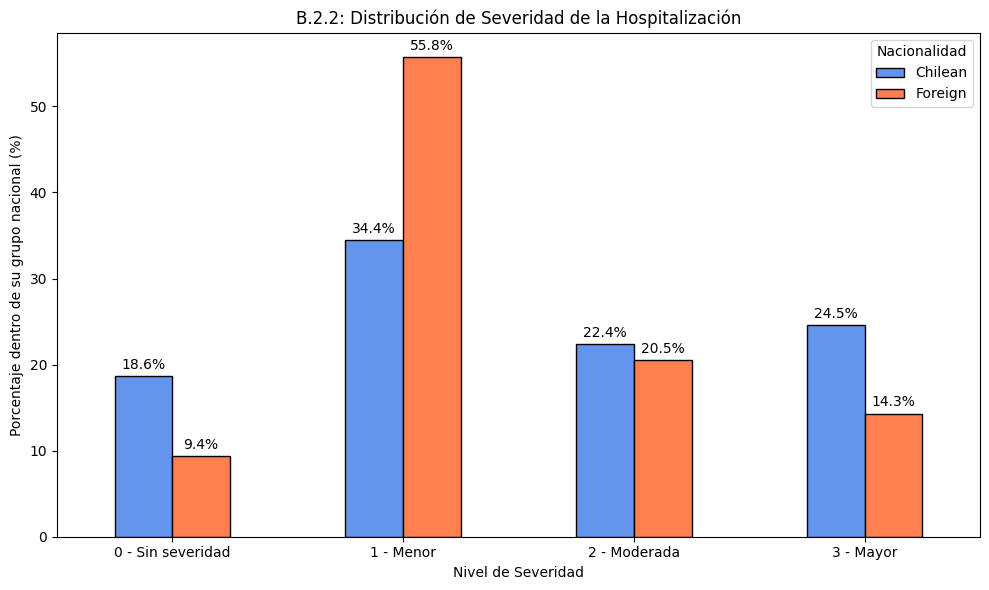


--- B.2.3 Tipo de Alta y Mortalidad Intrahospitalaria ---
Distribución General de Tipos de Alta (Top 5):
TIPOALTA
DOMICILIO                                40020
HOSPITALIZACIÓN DOMICILIARIA              2166
FALLECIDO                                 1545
ALTA VOLUNTARIA                            508
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO      350
Name: count, dtype: int64

Tasa de Mortalidad por Nacionalidad:


,Tasa de Mortalidad Intrahospitalaria (%)
nat_group,
Chilean,3.64
Foreign,1.01


In [ ]:
# ---------------------------------------------------------
# B.2.1 Length of stay by nationality
# ---------------------------------------------------------
print("--- B.2.1 Estancia Hospitalaria (LOS) por Nacionalidad ---")
# 1. Tabla de Media y Mediana
los_stats = grd_com.groupby('nat_group')['los'].agg(['mean', 'median']).round(2)
los_stats.columns = ['Media (Días)', 'Mediana (Días)']
display(los_stats)

# 2. Gráfico de distribución (histogramas superpuestos, tope en 30 días)
fig, ax1 = plt.subplots(figsize=(10, 6))
grd_los_30 = grd_com[grd_com['los'] <= 30]

chilenos_los = grd_los_30[grd_los_30['nat_group'] == 'Chilean']['los']
extranjeros_los = grd_los_30[grd_los_30['nat_group'] == 'Foreign']['los']

# Usamos density=True para comparar justamente proporciones, ya que hay muchos más chilenos que extranjeros
ax1.hist(chilenos_los, bins=30, alpha=0.5, label='Chilean', color='cornflowerblue', density=True, edgecolor='black')
ax1.hist(extranjeros_los, bins=30, alpha=0.5, label='Foreign', color='coral', density=True, edgecolor='black')

ax1.set_title("B.2.1: Distribución de Días de Estadía Hospitalaria (Capped at 30 days)")
ax1.set_xlabel("Días de Hospitalización (LOS)")
ax1.set_ylabel("Frecuencia Relativa")
ax1.legend(title="Nacionalidad")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B.2.2 Severity distribution
# ---------------------------------------------------------
print("\n--- B.2.2 Distribución de Severidad por Nacionalidad ---")

# ¡LA CORRECCIÓN!: Forzamos la columna a ser un número real antes de mapear
grd_com['IR_29301_SEVERIDAD'] = pd.to_numeric(grd_com['IR_29301_SEVERIDAD'], errors='coerce')

# Mapeo de severidad según instrucciones
sev_map = {0: '0 - Sin severidad', 1: '1 - Menor', 2: '2 - Moderada', 3: '3 - Mayor'}
grd_com['severidad_label'] = grd_com['IR_29301_SEVERIDAD'].map(sev_map)

# Calculamos distribución
sev_nac = grd_com.groupby(['severidad_label', 'nat_group']).size().unstack(fill_value=0)
# Calculamos el % DENTRO de cada grupo nacional para poder compararlos cara a cara
sev_nac_pct = sev_nac.div(sev_nac.sum(axis=0), axis=1) * 100

fig, ax2 = plt.subplots(figsize=(10, 6))
sev_nac_pct.plot(kind='bar', color=['cornflowerblue', 'coral'], edgecolor='black', ax=ax2)

ax2.set_title("B.2.2: Distribución de Severidad de la Hospitalización")
ax2.set_ylabel("Porcentaje dentro de su grupo nacional (%)")
ax2.set_xlabel("Nivel de Severidad")
ax2.legend(title="Nacionalidad")
plt.xticks(rotation=0)

# Añadir etiquetas
for c in ax2.containers:
    ax2.bar_label(c, fmt='%.1f%%', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B.2.3 Discharge type & In-hospital mortality
# ---------------------------------------------------------
print("\n--- B.2.3 Tipo de Alta y Mortalidad Intrahospitalaria ---")
# Estandarizamos el texto por seguridad (quitar espacios invisibles y pasar a mayúsculas)
grd_com['TIPOALTA'] = grd_com['TIPOALTA'].astype(str).str.strip().str.upper()

print("Distribución General de Tipos de Alta (Top 5):")
print(grd_com['TIPOALTA'].value_counts().head(5))

# Tasa de Mortalidad (% de altas que son "FALLECIDO")
grd_com['fallecido'] = (grd_com['TIPOALTA'] == 'FALLECIDO').astype(int)
mortality = grd_com.groupby('nat_group')['fallecido'].mean() * 100

mortality_df = mortality.to_frame(name="Tasa de Mortalidad Intrahospitalaria (%)").round(2)
print("\nTasa de Mortalidad por Nacionalidad:")
display(mortality_df)

## B.3: Spatial View | B.4: Comuna-Level GRD Summary Table

Importancia del Código Ejecutado

Esta fase final es la más potente desde el punto de vista de la inteligencia sanitaria, ya que cruza la gestión clínica con la geografía:

- Construcción de Indicadores Complejos (B.4): El uso de groupby y funciones personalizadas permite calcular en un solo paso métricas de eficiencia (estancia media), severidad, mortalidad y volumen migratorio. Esto transforma datos crudos en una herramienta de gestión para directores de hospitales.

- Visualización Espacial (B.3): La generación de un mapa coroplético utilizando geopandas es fundamental para identificar patrones territoriales. Al graficar la tasa normalizada, se eliminan las distorsiones visuales causadas por el tamaño de la población, permitiendo ver dónde está el verdadero "calor" de la demanda hospitalaria.

- Integración Inter-Tarea: El merge con los datos de la Tarea 1 demuestra la capacidad de mantener la trazabilidad de la información a lo largo de todo el proyecto.

Interpretación de Resultados

La tabla resumen y el mapa coroplético revelan hallazgos críticos sobre el uso de la red hospitalaria en las tres comunas:

- Distribución del Riesgo Hospitalario: A diferencia de las notificaciones obligatorias, Cerro Navia presenta la tasa de hospitalización más alta con 2207.55 egresos por cada 10.000 habitantes, seguida por Pedro Aguirre Cerda (1628.79) y Vitacura (209.35). Esto indica que la presión sobre las camas hospitalarias es significativamente mayor en las comunas con indicadores de vulnerabilidad más altos.

- Complejidad y Mortalidad en el Sector Sur: Es notable que Pedro Aguirre Cerda presenta la mayor estancia media (6.55 días) y la mayor tasa de mortalidad intrahospitalaria (3.62%). Además, registra la mayor severidad media con 1.62, lo que sugiere que sus pacientes ingresan con cuadros clínicos de mayor gravedad en comparación con Vitacura, que tiene una severidad de 1.30.

- Carga Migratoria Variable: La proporción de extranjeros en las hospitalizaciones varía entre los territorios, siendo Vitacura la que lidera este indicador con un 13.41% de egresos correspondientes a pacientes extranjeros, seguida por Cerro Navia con un 8.34%.

- Diagnósticos Prevalentes y Contrastes Territoriales: Los capítulos de Embarazo, parto y puerperio dominan el Top 3 en Cerro Navia y PAC, confirmando que en estos sectores la red se utiliza fuertemente para servicios obstétricos. En contraste, en Vitacura el diagnóstico principal es Neoplasias (Cáncer), seguido de Enfermedades del ojo, reflejando una demanda volcada a patologías crónicas y de especialidad.


Archivo 'tarea1_comuna_summary.csv' cargado correctamente.

--- B.4 Construyendo Tabla Resumen GRD (Entregable Final) ---
¡Éxito! El archivo 'tarea2_grd_summary.csv' ha sido generado y guardado en Colab.



,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13103,Cerro Navia,27846,25523,2323,8.34,6.38,6.49,5.19,1.48,3.37,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",2207.55
1,13121,Pedro Aguirre Cerda,15537,14355,1182,7.61,6.55,6.67,5.11,1.62,3.62,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1628.79
2,13132,Vitacura,1790,1550,240,13.41,5.19,5.39,3.85,1.30,2.46,"Cap.02 NEOPLASIAS (C00-D49), Cap.07 ENFERMED...",209.35



--- B.3.1 Mapa de Tasas de Hospitalización por Comuna ---


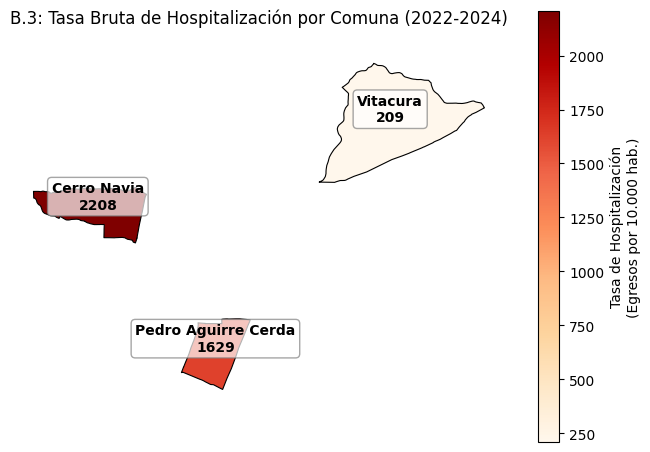

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Preparativos: Mapeo de Comunas y Carga de Población
# ---------------------------------------------------------
# 1. Mapeamos los nombres en mayúsculas del GRD a los códigos numéricos del Censo
map_nombres_codigos = {
    "VITACURA": 13132,
    "PEDRO AGUIRRE CERDA": 13121,
    "CERRO NAVIA": 13103
}
grd_com['codigo_comuna'] = grd_com['COMUNA'].map(map_nombres_codigos)

# 2. Cargamos la población de la Tarea 1
try:
    tarea1 = pd.read_csv("tarea1_comuna_summary.csv")
    print("Archivo 'tarea1_comuna_summary.csv' cargado correctamente.\n")
except FileNotFoundError:
    print("ERROR: No se encontró 'tarea1_comuna_summary.csv'.")

# ---------------------------------------------------------
# B.4 Comuna-Level GRD Summary Table (Lo calculamos primero para usar las tasas en el mapa)
# ---------------------------------------------------------
print("--- B.4 Construyendo Tabla Resumen GRD (Entregable Final) ---")

def build_grd_summary(grupo):
    grd_total = len(grupo)
    grd_chilean = (grupo['nat_group'] == 'Chilean').sum()
    grd_foreign = (grupo['nat_group'] == 'Foreign').sum()
    grd_pct_foreign = (grd_foreign / grd_total * 100) if grd_total > 0 else 0

    # Estancia media
    grd_mean_los = grupo['los'].mean()
    grd_mean_los_chilean = grupo[grupo['nat_group'] == 'Chilean']['los'].mean()
    grd_mean_los_foreign = grupo[grupo['nat_group'] == 'Foreign']['los'].mean()

    # Severidad media
    grd_mean_severity = pd.to_numeric(grupo['IR_29301_SEVERIDAD'], errors='coerce').mean()

    # Mortalidad (% de FALLECIDO)
    grd_mortality_rate = (grupo['TIPOALTA'] == 'FALLECIDO').mean() * 100

    # Top 3 capítulos
    top3 = grupo['Capítulo'].value_counts().head(3).index.tolist()
    grd_top3_chapters = ", ".join(top3)

    return pd.Series({
        'grd_total': grd_total,
        'grd_chilean': grd_chilean,
        'grd_foreign': grd_foreign,
        'grd_pct_foreign': grd_pct_foreign,
        'grd_mean_los': grd_mean_los,
        'grd_mean_los_chilean': grd_mean_los_chilean,
        'grd_mean_los_foreign': grd_mean_los_foreign,
        'grd_mean_severity': grd_mean_severity,
        'grd_mortality_rate': grd_mortality_rate,
        'grd_top3_chapters': grd_top3_chapters
    })

# 1. Agrupamos por código y nombre (usando la estrategia segura que aprendimos)
grd_summary = grd_com.groupby(['codigo_comuna', 'COMUNA']).apply(build_grd_summary, include_groups=False).reset_index()

# Renombramos y embellecemos el nombre de la comuna (ej: "VITACURA" -> "Vitacura")
grd_summary.rename(columns={'COMUNA': 'nombre_comuna'}, inplace=True)
grd_summary['nombre_comuna'] = grd_summary['nombre_comuna'].str.title()

# 2. Cruzamos con los datos poblacionales de la Tarea 1
grd_summary = grd_summary.merge(tarea1[['codigo_comuna', 'pop_total']], on='codigo_comuna', how='left')

# 3. Calculamos la Tasa Bruta de Hospitalización (por 10.000 habs.)
grd_summary['grd_rate_per_10k'] = (grd_summary['grd_total'] / grd_summary['pop_total']) * 10000

# 4. Eliminamos la columna poblacional para dejarla idéntica a la rúbrica del profesor
grd_summary.drop(columns=['pop_total'], inplace=True)

# Exportamos a CSV
nombre_archivo = "tarea2_grd_summary.csv"
grd_summary.to_csv(nombre_archivo, index=False)
print(f"¡Éxito! El archivo '{nombre_archivo}' ha sido generado y guardado en Colab.\n")

# Mostrar la tabla formateada
pd.options.display.float_format = '{:.2f}'.format
display(grd_summary)

# ---------------------------------------------------------
# B.3.1 Choropleth: hospitalization rate by comuna
# ---------------------------------------------------------
print("\n--- B.3.1 Mapa de Tasas de Hospitalización por Comuna ---")

try:
    comunas_gdf = gpd.read_file("comunas.shp")

    # Buscar dinámicamente la columna que contiene los códigos de comuna
    col_codigo = None
    for col in comunas_gdf.columns:
        if comunas_gdf[col].astype(str).str.contains('13132').any():
            col_codigo = col
            break

    if col_codigo:
        # Forzar a numérico y filtrar a nuestras 3 comunas
        comunas_gdf[col_codigo] = pd.to_numeric(comunas_gdf[col_codigo])
        mis_comunas_gdf = comunas_gdf[comunas_gdf[col_codigo].isin([13132, 13121, 13103])].copy()

        # Unir el mapa con nuestra tabla resumen (para tener la tasa de hospitalización)
        mis_comunas_gdf = mis_comunas_gdf.merge(grd_summary[['codigo_comuna', 'grd_rate_per_10k', 'nombre_comuna']],
                                                left_on=col_codigo, right_on='codigo_comuna')

        # Dibujar el Mapa Coroplético
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        mis_comunas_gdf.plot(column='grd_rate_per_10k', cmap='OrRd', linewidth=0.8, ax=ax,
                             edgecolor='black', legend=True,
                             legend_kwds={'label': "Tasa de Hospitalización\n(Egresos por 10.000 hab.)", 'shrink': 0.7})

        # Agregar etiquetas de nombres y tasas directamente en el mapa
        for idx, row in mis_comunas_gdf.iterrows():
            etiqueta = f"{row['nombre_comuna']}\n{row['grd_rate_per_10k']:.0f}"
            ax.annotate(text=etiqueta, xy=row.geometry.centroid.coords[0],
                        ha='center', fontsize=10, weight='bold', color='black',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))

        ax.set_title("B.3: Tasa Bruta de Hospitalización por Comuna (2022-2024)")
        ax.axis('off')
        plt.show()
    else:
        print("Error: No encontré la columna con los códigos numéricos en el shapefile.")
except Exception as e:
    print(f"Error al cargar o dibujar el mapa: {e}")